## Step 1: Load the Dataset and Initial Exploration

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/credit_risk_dataset.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display the shape of the DataFrame
print('\nShape of the dataset (rows, columns):')
print(df.shape)

# Display a concise summary of the DataFrame, including data types and non-null values
print('\nInformation about the dataset:')
df.info()

First 5 rows of the dataset:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Shape of the dataset (rows, columns):
(32581, 12)

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: fl

## Step 2: Handle Missing Values and Outliers

In [11]:
import numpy as np

# Handle outlier in 'person_emp_length': cap at 60 years
df['person_emp_length'] = df['person_emp_length'].apply(lambda x: 60 if x > 60 else x)

# Impute missing values in 'person_emp_length' with the median
median_emp_length = df['person_emp_length'].median()
df['person_emp_length'] = df['person_emp_length'].fillna(median_emp_length)

# Impute missing values in 'loan_int_rate' with the median
median_int_rate = df['loan_int_rate'].median()
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_int_rate)

# Verify that there are no more missing values and check the updated info
print('Information about the dataset after handling missing values and outliers:')
df.info()

# Display descriptive statistics for the affected columns to see the changes
print('\nDescriptive statistics for person_emp_length and loan_int_rate:')
display(df[['person_emp_length', 'loan_int_rate']].describe())

Information about the dataset after handling missing values and outliers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3),

,person_emp_length,loan_int_rate
count,32581.000000,32581.000000
mean,4.764126,11.009620
std,4.004465,3.081611
min,0.000000,5.420000
25%,2.000000,8.490000
50%,4.000000,10.990000
75%,7.000000,13.110000
max,60.000000,23.220000


## Step 3: Feature Engineering and Data Preparation

First 5 rows of the DataFrame after one-hot encoding:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,60.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True



Information about the encoded dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32581 non-null  int64  
 1   person_income                32581 non-null  int64  
 2   person_emp_length            32581 non-null  float64
 3   loan_amnt                    32581 non-null  int64  
 4   loan_int_rate                32581 non-null  float64
 5   loan_status                  32581 non-null  int64  
 6   loan_percent_income          32581 non-null  float64
 7   cb_person_cred_hist_length   32581 non-null  int64  
 8   person_home_ownership_OTHER  32581 non-null  bool   
 9   person_home_ownership_OWN    32581 non-null  bool   
 10  person_home_ownership_RENT   32581 non-null  bool   
 11  loan_intent_EDUCATION        32581 non-null  bool   
 12  loan_intent_HOMEIMPROVEMENT  32581

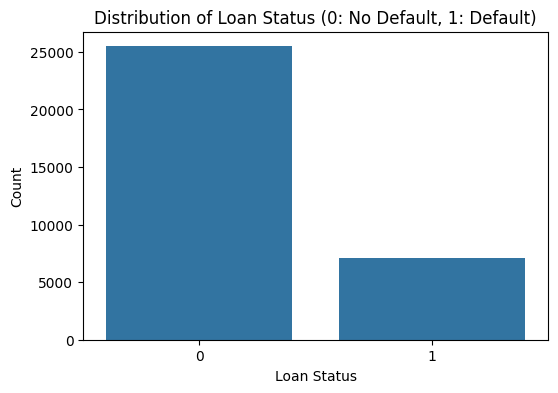

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame
print('First 5 rows of the DataFrame after one-hot encoding:')
display(df_encoded.head())

# Display information about the encoded DataFrame to see new columns and types
print('\nInformation about the encoded dataset:')
df_encoded.info()

# Visualize the distribution of the target variable 'loan_status'
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df_encoded)
plt.title('Distribution of Loan Status (0: No Default, 1: Default)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

## Step 4: Handle Class Imbalance, Data Splitting, and Feature Scaling

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split the data into training and testing sets before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original training set shape: {X_train.shape}")
print(f"Original testing set shape: {X_test.shape}")
print(f"Original training target distribution:\n{y_train.value_counts()}")

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nResampled training set shape: {X_train_resampled.shape}")
print(f"Resampled training target distribution:\n{y_train_resampled.value_counts()}")

# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns for scaling
# Exclude boolean columns as they are already 0 or 1 and don't need scaling
numerical_cols = X_train_resampled.select_dtypes(include=['int64', 'float64']).columns

# Fit and transform the training data, transform the test data
X_train_scaled = X_train_resampled.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_resampled[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print('\nFirst 5 rows of scaled training features (numerical columns):')
display(X_train_scaled[numerical_cols].head())

print('\nFirst 5 rows of scaled testing features (numerical columns):')
display(X_test_scaled[numerical_cols].head())

Original training set shape: (26064, 22)
Original testing set shape: (6517, 22)
Original training target distribution:
loan_status
0    20378
1     5686
Name: count, dtype: int64

Resampled training set shape: (40756, 22)
Resampled training target distribution:
loan_status
0    20378
1    20378
Name: count, dtype: int64

First 5 rows of scaled training features (numerical columns):


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
0,-0.406209,3.239228,-0.138335,0.899192,-1.506638,-1.053095,-0.409156
1,-1.079079,-0.746620,0.129042,-1.285192,0.164934,-0.970711,-0.409156
2,-0.406209,-0.123484,1.465928,0.899192,0.278979,0.841754,-0.933387
3,0.098443,-0.767985,-0.138335,-0.757927,0.751451,0.841754,0.639308
4,-0.406209,-0.176896,-0.673089,-0.004691,-1.229671,0.017906,-0.933387



First 5 rows of scaled testing features (numerical columns):


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
6616,-0.910862,-0.176896,0.396419,-0.607280,0.070440,-0.641172,-0.933387
21802,0.771313,-0.141288,-1.207843,-0.437802,-1.363267,-0.476402,1.163539
31886,1.612401,2.582709,-0.405712,1.200486,-0.418324,-0.888326,2.212002
17799,-0.237992,0.713299,0.129042,2.104369,-0.222818,0.347445,-0.409156
5207,-0.742644,-0.277666,-1.207843,-1.059221,0.425608,-1.053095,-0.671271


## Step 5: Model Training and Evaluation - Logistic Regression

Logistic Regression Model Performance:
Accuracy: 0.8364
Precision: 0.6234
Recall: 0.6322
F1-Score: 0.6278

Confusion Matrix:
[[4552  543]
 [ 523  899]]


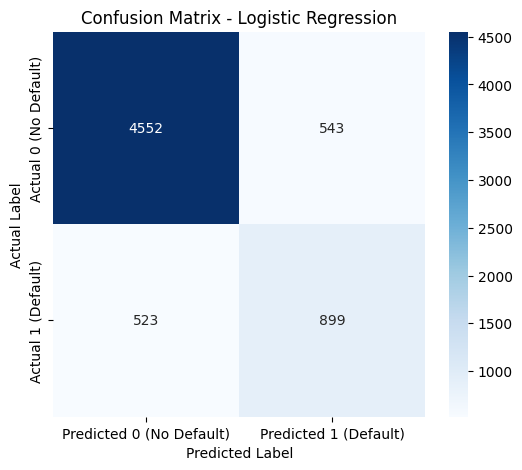

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and L1/L2 regularization
log_reg.fit(X_train_scaled, y_train_resampled)

# Make predictions on the scaled test set
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_log_reg)

# Plotting the confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (No Default)', 'Predicted 1 (Default)'],
            yticklabels=['Actual 0 (No Default)', 'Actual 1 (Default)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 6: Model Training and Evaluation - Decision Tree Classifier

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters for Decision Tree: {'dt__criterion': 'gini', 'dt__max_depth': 15, 'dt__min_samples_leaf': 1}

Decision Tree Classifier Model Performance:
Accuracy: 0.9138
Precision: 0.8638
Recall: 0.7180
F1-Score: 0.7842

Confusion Matrix:
[[4934  161]
 [ 401 1021]]


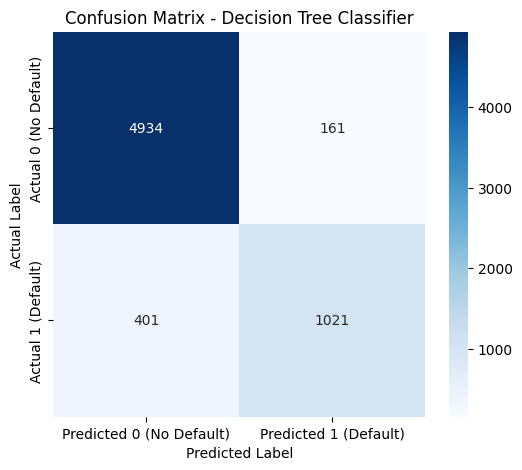

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Create a pipeline with a Decision Tree Classifier
pipeline_dt = Pipeline([
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Define the parameter grid for GridSearchCV
param_grid_dt = {
    'dt__max_depth': [5, 10, 15, 20],
    'dt__min_samples_leaf': [1, 5, 10],
    'dt__criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the resampled training data
grid_search_dt.fit(X_train_scaled, y_train_resampled)

# Get the best Decision Tree model
best_dt_model = grid_search_dt.best_estimator_

print("Best parameters for Decision Tree:", grid_search_dt.best_params_)

# Make predictions on the scaled test set using the best model
y_pred_dt = best_dt_model.predict(X_test_scaled)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print(f"\nDecision Tree Classifier Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_dt)

# Plotting the confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (No Default)', 'Predicted 1 (Default)'],
            yticklabels=['Actual 0 (No Default)', 'Actual 1 (Default)'])
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 7: Model Training and Evaluation - Random Forest Classifier

Random Forest Classifier Model Performance:
Accuracy: 0.9201
Precision: 0.8789
Recall: 0.7349
F1-Score: 0.8005

Confusion Matrix:
[[4951  144]
 [ 377 1045]]


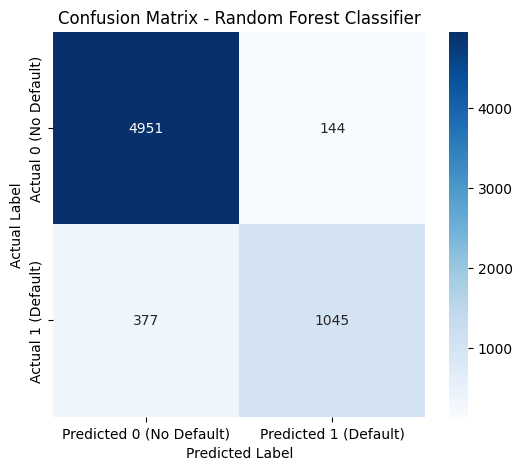

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100) # Using 100 estimators as a starting point
rf_classifier.fit(X_train_scaled, y_train_resampled)

# Make predictions on the scaled test set
y_pred_rf = rf_classifier.predict(X_test_scaled)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)

# Plotting the confusion matrix for better visualization
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (No Default)', 'Predicted 1 (Default)'],
            yticklabels=['Actual 0 (No Default)', 'Actual 1 (Default)'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Step 8: Compare Model Performance

In [8]:
# Create a dictionary to store the results
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_dt, accuracy_rf],
    'Precision': [precision_log_reg, precision_dt, precision_rf],
    'Recall': [recall_log_reg, recall_dt, recall_rf],
    'F1-Score': [f1_log_reg, f1_dt, f1_rf]
}

# Create a DataFrame from the results dictionary
results_df = pd.DataFrame(results)

# Display the results DataFrame, sorted by F1-Score (a good balance of precision and recall)
print("\nModel Performance Comparison:")
display(results_df.sort_values(by='F1-Score', ascending=False))


Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.920055,0.87889,0.734880,0.800460
1,Decision Tree,0.913764,0.86379,0.718003,0.784178
0,Logistic Regression,0.836428,0.62344,0.632208,0.627793


## Step 9: Evaluate Models with ROC AUC

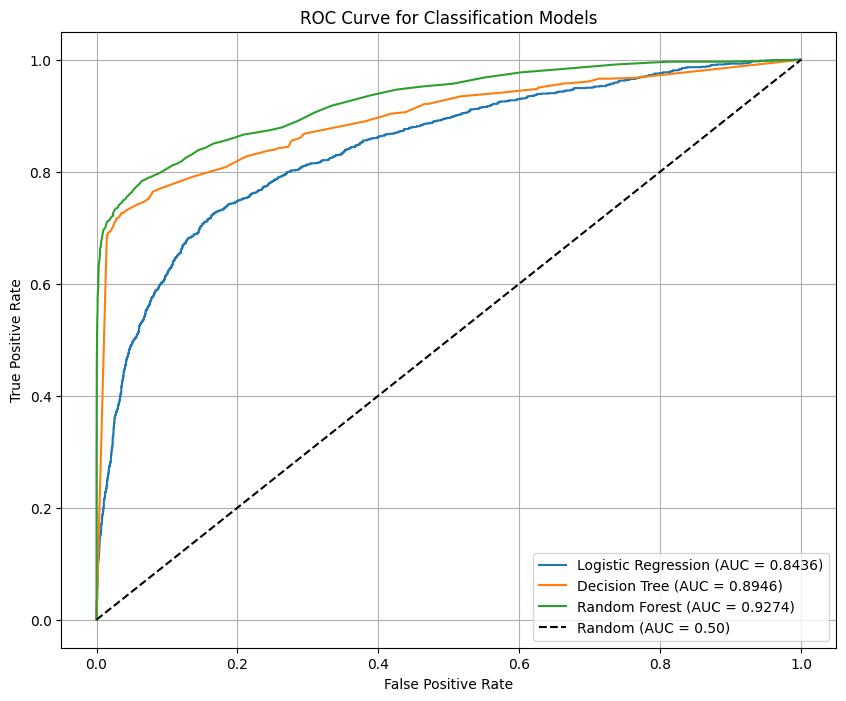


Updated Model Performance Comparison with AUC:


,Model,Accuracy,Precision,Recall,F1-Score,AUC
2,Random Forest,0.920055,0.87889,0.734880,0.800460,0.927443
1,Decision Tree,0.913764,0.86379,0.718003,0.784178,0.894636
0,Logistic Regression,0.836428,0.62344,0.632208,0.627793,0.843589


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 8))

# --- Logistic Regression ROC ---
y_pred_proba_log_reg = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_proba_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {auc_log_reg:.4f})')

# --- Decision Tree ROC ---
y_pred_proba_dt = best_dt_model.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})')

# --- Random Forest ROC ---
y_pred_proba_rf = rf_classifier.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

# --- Plotting settings ---
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)') # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classification Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Update the results DataFrame with AUC scores
results_df['AUC'] = [auc_log_reg, auc_dt, auc_rf]

print("\nUpdated Model Performance Comparison with AUC:")
display(results_df.sort_values(by='F1-Score', ascending=False))